In [1]:
# === STEP 1: Import Libraries & Connect (if not already done) ===
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("stackoverflow.db")

# 100k

In [3]:
# === STEP 2: Aggregate Upvotes and Downvotes Per Month (LIMIT 5M) ===
query = """
    SELECT 
        strftime('%Y-%m', CreationDate) AS YearMonth,
        SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
        SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
    FROM votes
    WHERE CreationDate IS NOT NULL
    LIMIT 100000
"""
votes_df = pd.read_sql_query(query, conn)

In [4]:
votes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   YearMonth  1 non-null      object
 1   Upvotes    1 non-null      int64 
 2   Downvotes  1 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 156.0+ bytes


In [5]:
votes_df.head()

,YearMonth,Upvotes,Downvotes
0,2008-07,157835165,15773182


In [6]:
# # Fill any nulls (just in case)
# votes_df = votes_df.fillna(0)

C:\Users\Ola\AppData\Local\Temp\ipykernel_18012\3254339322.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


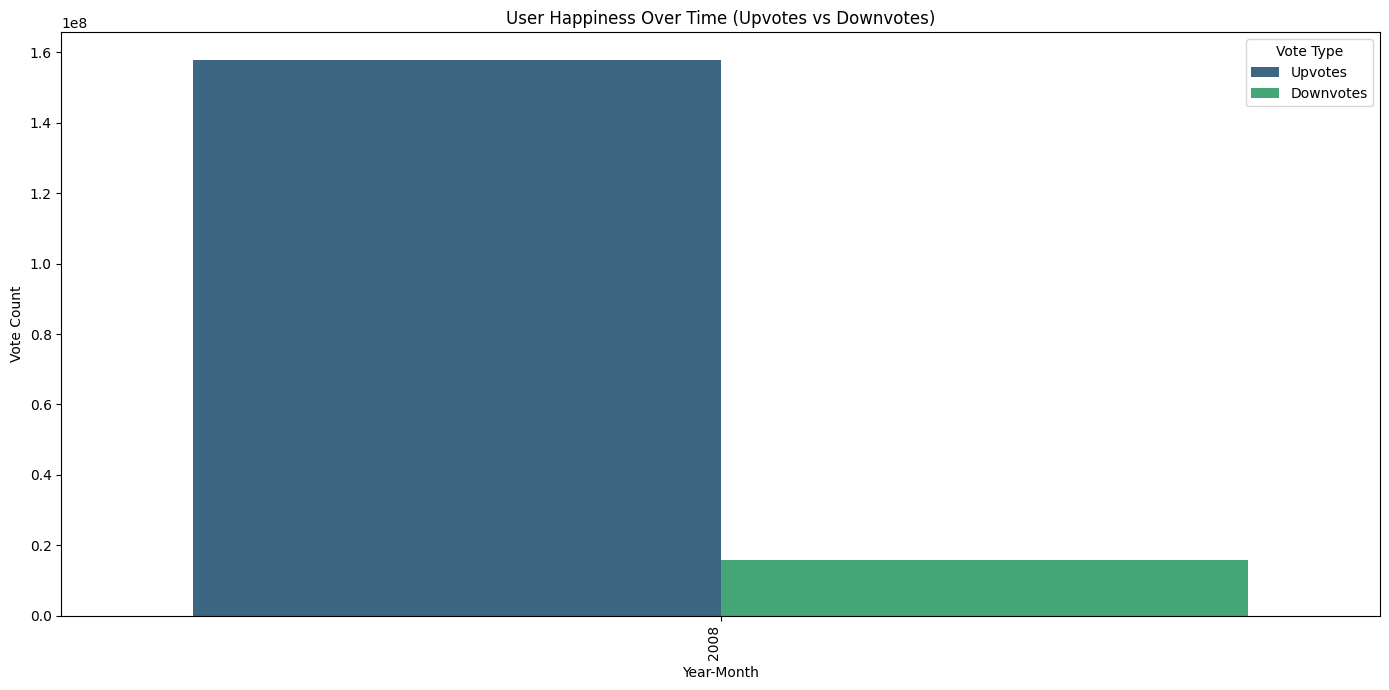

In [7]:
# === STEP 3: Plot Happiness Over Time ===
plt.figure(figsize=(14, 7))
votes_melted = votes_df.melt(id_vars="YearMonth", value_vars=["Upvotes", "Downvotes"],
                              var_name="VoteType", value_name="Count")

ax = sns.barplot(data=votes_melted, x="YearMonth", y="Count", hue="VoteType", palette="viridis")
plt.title("User Happiness Over Time (Upvotes vs Downvotes)")
plt.xlabel("Year-Month")
plt.ylabel("Vote Count")
plt.xticks(rotation=90, ha='right')
plt.legend(title="Vote Type")

# Grouped year labels for x-axis
year_month_pattern = []
unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()


Now I will try the same, but with more rows
# 1M

In [8]:
# === STEP 2: Aggregate Upvotes and Downvotes Per Month (LIMIT 5M) ===
query = """
    SELECT 
        strftime('%Y-%m', CreationDate) AS YearMonth,
        SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
        SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
    FROM votes
    WHERE CreationDate IS NOT NULL
    LIMIT 1000000
"""
votes_df = pd.read_sql_query(query, conn)

In [9]:
votes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   YearMonth  1 non-null      object
 1   Upvotes    1 non-null      int64 
 2   Downvotes  1 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 156.0+ bytes


In [10]:
votes_df.head()

,YearMonth,Upvotes,Downvotes
0,2008-07,157835165,15773182


In [11]:
# # Fill any nulls (just in case)
# votes_df = votes_df.fillna(0)

C:\Users\Ola\AppData\Local\Temp\ipykernel_18012\3307969802.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


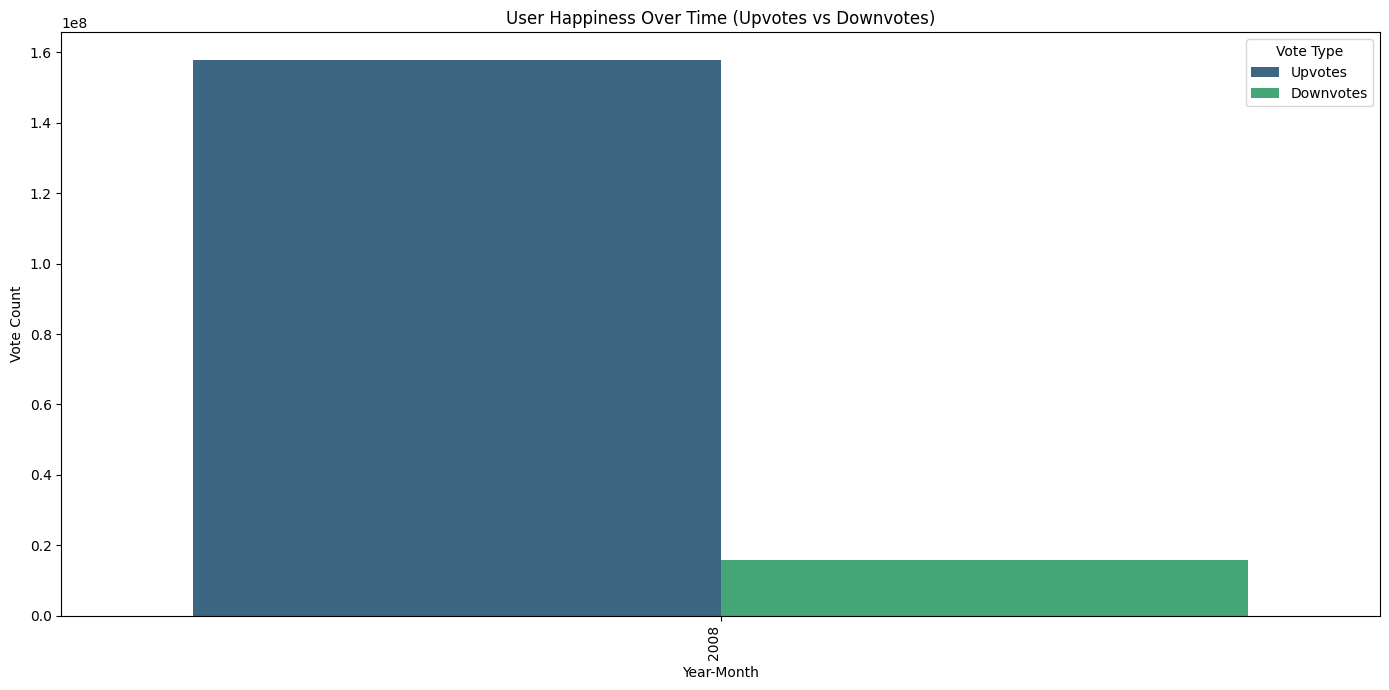

In [12]:
# === STEP 3: Plot Happiness Over Time ===
plt.figure(figsize=(14, 7))
votes_melted = votes_df.melt(id_vars="YearMonth", value_vars=["Upvotes", "Downvotes"],
                              var_name="VoteType", value_name="Count")

ax = sns.barplot(data=votes_melted, x="YearMonth", y="Count", hue="VoteType", palette="viridis")
plt.title("User Happiness Over Time (Upvotes vs Downvotes)")
plt.xlabel("Year-Month")
plt.ylabel("Vote Count")
plt.xticks(rotation=90, ha='right')
plt.legend(title="Vote Type")

# Grouped year labels for x-axis
year_month_pattern = []
unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()

I have just run this code in JN, first for 100k rows, then for 1M rows. The charts are identical so maybe something si not right? i mean in the sql query? can i first have a look at the data, perhaps let's explore it in first 10-20 as pandas df? how do you know what VoteTypeId counts as Upvote and what as Downvote?


ChatGPT said:
You're asking all the right things 👏 and you're absolutely right to check — if the charts look identical for different limits, that likely means the LIMIT is affecting rows before grouping, which isn't what we want for aggregation.

🔍 1. Let's Explore the Raw votes Table
Let’s preview a small raw sample from the votes table to better understand what's inside:

In [13]:
# Preview 20 raw rows from the votes table
sample_votes = pd.read_sql_query("SELECT * FROM votes LIMIT 20", conn)
print(sample_votes)


    Id  PostId  VoteTypeId             CreationDate
0    1       1           2  2008-07-31T00:00:00.000
1    2       3           2  2008-07-31T00:00:00.000
2    3       2           2  2008-07-31T00:00:00.000
3    4       4           2  2008-07-31T00:00:00.000
4    5       6           2  2008-07-31T00:00:00.000
5    6       7           2  2008-07-31T00:00:00.000
6    7      13           2  2008-08-01T00:00:00.000
7    9       4           2  2008-08-01T00:00:00.000
8   10      12           2  2008-08-01T00:00:00.000
9   11      13           2  2008-08-01T00:00:00.000
10  16      19           2  2008-08-01T00:00:00.000
11  19      15           2  2008-08-01T00:00:00.000
12  20      15           3  2008-08-01T00:00:00.000
13  26      15           3  2008-08-01T00:00:00.000
14  27      22           3  2008-08-01T00:00:00.000
15  32      25           2  2008-08-01T00:00:00.000
16  33      35           3  2008-08-01T00:00:00.000
17  34       7           2  2008-08-01T00:00:00.000
18  35      

This gives you a feel for the actual data and confirms how vote types are coded.

📊 2. What is VoteTypeId?
Based on Stack Overflow Data Dump documentation, here are the key vote types:

VoteTypeId	Meaning
1	AcceptedByOriginator
2	UpMod (Upvote)
3	DownMod (Downvote)
5	Offensive
8	BountyStart
9	BountyClose
So yes — 2 is an upvote and 3 is a downvote. ✅



https://meta.stackexchange.com/questions/2677/database-schema-documentation-for-the-public-data-dump-and-sede

🚨 What's Likely Going Wrong?
When we use:

``LIMIT 5000000``
before GROUP BY, SQLite stops after 5M rows — but it might be selecting only the first few months in the dataset (or repeating the same month). That’s why your chart doesn’t change.

Absolutely — let's break it down carefully and clearly, both in English and Polish 🇬🇧🇵🇱

🔍 What's Likely Going Wrong? (EN)
In your current SQL query:

sql
Copy
Edit
SELECT 
    strftime('%Y-%m', CreationDate) AS YearMonth,
    SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
    SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
FROM votes
WHERE CreationDate IS NOT NULL
LIMIT 5000000
You're asking SQLite to:

Pull the first 5,000,000 rows (LIMIT 5000000)

Then aggregate them (sum and group by month)

However, this is not the same as getting a full monthly summary of the whole table — it's just summarizing only the first 5 million rows, which might all belong to the same year/month or small time range (e.g. just July 2008 to Sept 2008).

That’s why the chart doesn’t change when you increase from 100k to 1M — you're still only seeing the earliest rows, not the whole timeline.

🔍 Co Prawdopodobnie Jest Nie Tak? (PL)
W twoim zapytaniu SQL:

sql
Copy
Edit
SELECT 
    strftime('%Y-%m', CreationDate) AS YearMonth,
    SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
    SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
FROM votes
WHERE CreationDate IS NOT NULL
LIMIT 5000000
SQLite:

Najpierw bierze tylko pierwsze 5 milionów wierszy (LIMIT 5000000)

A dopiero potem robi podsumowanie (suma głosów i grupowanie po miesiącu)

To oznacza, że widoczny wykres pokazuje tylko pierwsze miesiące danych (np. tylko lipiec–wrzesień 2008), dlatego wygląda identycznie niezależnie od tego, czy używasz 100 tys. czy 1 mln wierszy.

🛠️ Fix: Aggregate Everything, Then Limit in pandas (EN)
Instead of limiting SQL rows before aggregation, we remove LIMIT from SQL and:

Let SQLite calculate the full summary (for all months)

Then if the result is too long, we slice it in pandas, e.g. votes_df.head(20)

🛠️ Poprawka: Agreguj Wszystko, Potem Ogranicz w pandas (PL)
Zamiast ograniczać liczbę wierszy w SQL (przed podsumowaniem), należy:

Usunąć LIMIT z SQL

Pozwolić SQLite wykonać agregację dla całego zbioru danych

Jeśli wynik ma za dużo wierszy, ograniczamy go dopiero w pandas, np. votes_df.head(20)

Would you like me to rewrite the SQL query without LIMIT and apply a limit in pandas instead?

In [14]:
# # === STEP 1: Import Libraries & Connect ===
# import pandas as pd
# import sqlite3
# import seaborn as sns
# import matplotlib.pyplot as plt

# conn = sqlite3.connect("stackoverflow.db")

# # === STEP 2: Aggregate Upvotes and Downvotes Per Month (No LIMIT) ===
# query = """
#     SELECT 
#         strftime('%Y-%m', CreationDate) AS YearMonth,
#         SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
#         SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
#     FROM votes
#     WHERE CreationDate IS NOT NULL
#     GROUP BY YearMonth
#     ORDER BY YearMonth
# """
# votes_df = pd.read_sql_query(query, conn)

# # Optional: preview first few months only
# # votes_df = votes_df.head(20)

# # Fill any nulls just in case
# votes_df = votes_df.fillna(0)

# # === STEP 3: Plot Happiness Over Time ===
# plt.figure(figsize=(14, 7))
# votes_melted = votes_df.melt(id_vars="YearMonth", value_vars=["Upvotes", "Downvotes"],
#                               var_name="VoteType", value_name="Count")

# ax = sns.barplot(data=votes_melted, x="YearMonth", y="Count", hue="VoteType", palette="viridis")
# plt.title("User Happiness Over Time (Upvotes vs Downvotes)")
# plt.xlabel("Year-Month")
# plt.ylabel("Vote Count")
# plt.xticks(rotation=90, ha='right')
# plt.legend(title="Vote Type")

# # Grouped year labels
# year_month_pattern = []
# unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

# for year in unique_years:
#     year_month_pattern.append(year)
#     year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

# ax.set_xticklabels(year_month_pattern)

# plt.tight_layout()
# plt.show()


In [15]:
# === STEP 2: Aggregate Upvotes and Downvotes Per Month (No LIMIT) ===
query = """
    SELECT 
        strftime('%Y-%m', CreationDate) AS YearMonth,
        SUM(CASE WHEN VoteTypeId = 2 THEN 1 ELSE 0 END) AS Upvotes,
        SUM(CASE WHEN VoteTypeId = 3 THEN 1 ELSE 0 END) AS Downvotes
    FROM votes
    WHERE CreationDate IS NOT NULL
    GROUP BY YearMonth
    ORDER BY YearMonth
"""
votes_df = pd.read_sql_query(query, conn)

In [16]:
# # Optional: preview first few months only - don't need this because I have already this in sql query: WHERE CreationDate IS NOT NULL
# votes_df.head(20)

In [17]:
votes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   YearMonth  189 non-null    object
 1   Upvotes    189 non-null    int64 
 2   Downvotes  189 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ KB


In [18]:
# # Fill any nulls just in case
# votes_df.fillna(0)

C:\Users\Ola\AppData\Local\Temp\ipykernel_18012\153826044.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


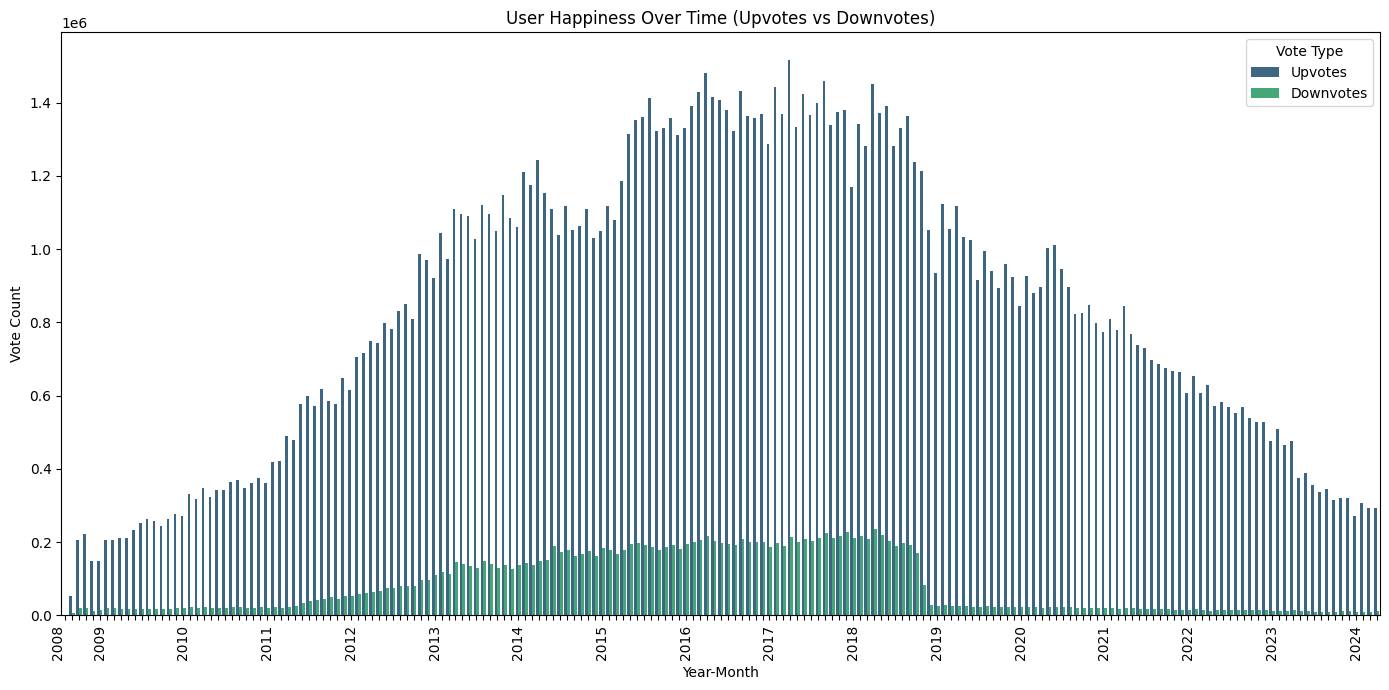

In [19]:
# === STEP 3: Plot Happiness Over Time ===
plt.figure(figsize=(14, 7))
votes_melted = votes_df.melt(id_vars="YearMonth", value_vars=["Upvotes", "Downvotes"],
                              var_name="VoteType", value_name="Count")

ax = sns.barplot(data=votes_melted, x="YearMonth", y="Count", hue="VoteType", palette="viridis")
plt.title("User Happiness Over Time (Upvotes vs Downvotes)")
plt.xlabel("Year-Month")
plt.ylabel("Vote Count")
plt.xticks(rotation=90, ha='right')
plt.legend(title="Vote Type")

# Grouped year labels
year_month_pattern = []
unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()


Yaaas, let’s do both Upvote % and Downvote % in one beautiful chart — it’s definitely more insightful that way 👀📈

✅ Why Plot Them Together?
They're complementary (together they add up to 100%)

You can instantly see if the platform is leaning more positive or negative each month

It's cleaner than toggling between two charts

 Code: Upvote & Downvote Percentages Over Time (Single Plot)

In [20]:
# === STEP 1: Calculate Upvote & Downvote Percentages ===
votes_df["TotalVotes"] = votes_df["Upvotes"] + votes_df["Downvotes"]
votes_df = votes_df[votes_df["TotalVotes"] > 0]  # avoid division by zero

votes_df["UpvotePercentage"] = (votes_df["Upvotes"] / votes_df["TotalVotes"]) * 100
votes_df["DownvotePercentage"] = (votes_df["Downvotes"] / votes_df["TotalVotes"]) * 100

In [21]:
# === STEP 2: Melt for Plotting ===
vote_pct = votes_df[["YearMonth", "UpvotePercentage", "DownvotePercentage"]].melt(
    id_vars="YearMonth",
    var_name="VoteType",
    value_name="Percentage"
)

C:\Users\Ola\AppData\Local\Temp\ipykernel_18012\3891731260.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


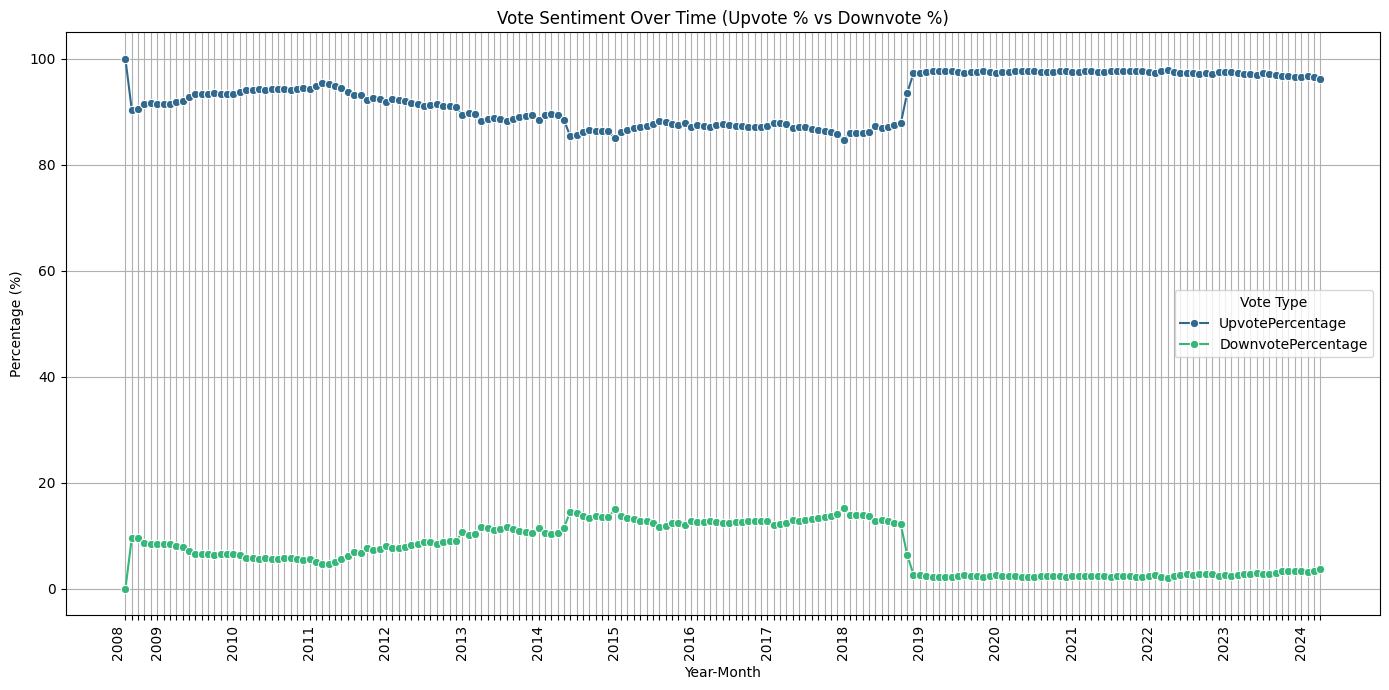

In [22]:
# === STEP 3: Plot ===
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=vote_pct, x="YearMonth", y="Percentage", hue="VoteType", palette="viridis", marker="o")

plt.title("Vote Sentiment Over Time (Upvote % vs Downvote %)")
plt.xlabel("Year-Month")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90, ha='right')
plt.legend(title="Vote Type")
plt.grid(True)

# Grouped year labels on x-axis (if needed)
year_month_pattern = []
unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()

improving charts for consintency with others

In [28]:
import matplotlib.ticker as mticker

C:\Users\Ola\AppData\Local\Temp\ipykernel_18012\3303249885.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


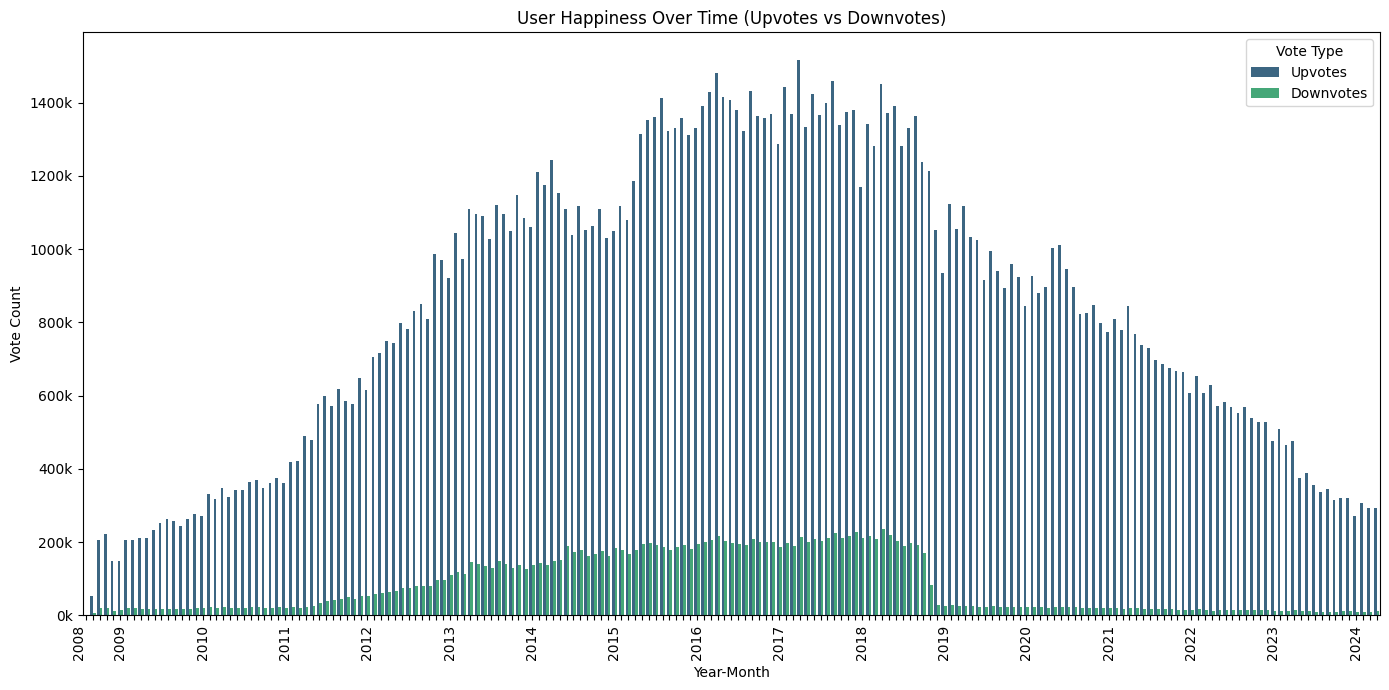

In [24]:
# === STEP 3: Plot Happiness Over Time ===
plt.figure(figsize=(14, 7))
votes_melted = votes_df.melt(id_vars="YearMonth", value_vars=["Upvotes", "Downvotes"],
                              var_name="VoteType", value_name="Count")

ax = sns.barplot(data=votes_melted, x="YearMonth", y="Count", hue="VoteType", palette="viridis")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
plt.title("User Happiness Over Time (Upvotes vs Downvotes)")
plt.xlabel("Year-Month")
plt.ylabel("Vote Count")
plt.xticks(rotation=90, ha='right')
plt.legend(title="Vote Type")

# Grouped year labels
year_month_pattern = []
unique_years = votes_df["YearMonth"].dropna().str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (votes_df["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()
